In [1]:
# ==============================================================================
# CELL 1: IMPORT LIBRARIES & SETUP CONFIGURATION
# ==============================================================================

import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta
from pathlib import Path

# ML Libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, VotingRegressor,
    StackingRegressor, BaggingRegressor, AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

# ==============================
# CONFIGURATION
# ==============================
BASE_DATA_DIR = "data"
OUTPUT_DIR = "ensemble_results"
MODELS_DIR = "models"
REGRESSION_DIR = os.path.join(MODELS_DIR, "regression")
SCALERS_DIR = os.path.join(MODELS_DIR, "scalers")
FORECAST_DIR = os.path.join(MODELS_DIR, "forecasts")

# Create directories
for dir_path in [OUTPUT_DIR, MODELS_DIR, REGRESSION_DIR, SCALERS_DIR, FORECAST_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print("✅ Thư mục đã được tạo:")
print(f"   Data: {BASE_DATA_DIR}")
print(f"   Models: {MODELS_DIR}")
print(f"   Output: {OUTPUT_DIR}")

✅ Thư mục đã được tạo:
   Data: data
   Models: models
   Output: ensemble_results


In [2]:
# ==============================================================================
# CELL 2: DATA PROCESSING & FEATURE SELECTION FUNCTIONS
# ==============================================================================
def load_and_preprocess(filepath):
    """Load và thêm features thời gian cơ bản"""
    df = pd.read_csv(filepath)
    df["date"] = pd.to_datetime(df["date"])
    
    # Temporal features
    df["sin_doy"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["cos_doy"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)
    df["month"] = df["date"].dt.month
    df["year"] = df["date"].dt.year
    df["day_of_month"] = df["date"].dt.day
    df["season"] = df["date"].dt.month % 12 // 3 + 1
    df["is_weekend"] = df["date"].dt.dayofweek >= 5
    
    return df

def add_features_without_leak(df, is_training=True):
    """
    Thêm features KHÔNG gây data leakage - ĐÃ SỬA CHO NĂM ĐẦU
    
    Args:
        df: DataFrame
        is_training: True nếu là training data, False nếu là prediction data
    """
    df = df.copy()
    
    # 1. Lag features - xử lý đặc biệt cho năm đầu
    lags = [1, 2, 3, 5, 7, 14, 30]
    
    for lag in lags:
        # Tính lag như bình thường
        df[f"wl_lag_{lag}"] = df["water_level"].shift(lag)
        
        if lag <= 7:
            df[f"rain_lag_{lag}"] = df["rainfall"].shift(lag)
            df[f"temp_lag_{lag}"] = df["temperature_2m_max"].shift(lag)
    
    # Lag 365 - đặc biệt quan trọng, cần xử lý cẩn thận
    df["wl_lag_365"] = df["water_level"].shift(365)
    
    # Nếu là training và không có đủ 365 ngày trước, forward fill từ ngày đầu tiên
    if is_training and df["wl_lag_365"].isna().any():
        # Tìm index của dòng đầu tiên không có lag 365
        first_valid_idx = df["wl_lag_365"].first_valid_index()
        if first_valid_idx is not None and first_valid_idx > 0:
            # Fill NaN với giá trị của water_level hiện tại (hoặc giá trị trung bình)
            mean_wl = df["water_level"].iloc[:first_valid_idx].mean()
            df["wl_lag_365"] = df["wl_lag_365"].fillna(mean_wl)
    
    # 2. Moving averages - SHIFT 1 để không leak
    for window in [3, 7, 14, 30]:
        # Tính moving average
        ma = df["water_level"].rolling(window=window, min_periods=1).mean()
        df[f"wl_ma_{window}"] = ma.shift(1)  # Dùng giá trị của ngày hôm qua
        
        ma_rain = df["rainfall"].rolling(window=window, min_periods=1).mean()
        df[f"rain_ma_{window}"] = ma_rain.shift(1)
        
        ma_temp = df["temperature_2m_max"].rolling(window=window, min_periods=1).mean()
        df[f"temp_ma_{window}"] = ma_temp.shift(1)
    
    # 3. Rolling statistics - SHIFT 1
    for window in [7, 14]:
        df[f"wl_std_{window}"] = df["water_level"].rolling(
            window=window, min_periods=1).std().shift(1)
        df[f"wl_min_{window}"] = df["water_level"].rolling(
            window=window, min_periods=1).min().shift(1)
        df[f"wl_max_{window}"] = df["water_level"].rolling(
            window=window, min_periods=1).max().shift(1)
    
    # 4. Interaction features
    if "rain_lag_1" in df.columns and "temp_lag_1" in df.columns:
        df["rain_temp_interaction"] = df["rain_lag_1"] * df["temp_lag_1"]
    
    if "precipitation_sum" in df.columns and "et0_fao_evapotranspiration" in df.columns:
        df["precip_evap_interaction"] = df["precipitation_sum"] * df["et0_fao_evapotranspiration"]
    
    if "rainfall" in df.columns and "precipitation_sum" in df.columns:
        df["rain_ratio"] = df["rainfall"] / (df["precipitation_sum"].replace(0, 1e-6) + 1e-6)
    
    # 5. Delta features - chỉ tính khi có đủ data
    for lag in [1, 3, 7]:
        lag_col = f"wl_lag_{lag}"
        if lag_col in df.columns:
            # Tính delta từ lag hiện tại và lag trước đó
            df[f"wl_delta_{lag}"] = df[lag_col] - df[lag_col].shift(1)
            
            # Fill NaN cho dòng đầu tiên bằng 0
            df[f"wl_delta_{lag}"] = df[f"wl_delta_{lag}"].fillna(0)
        
        rain_lag_col = f"rain_lag_{lag}"
        if rain_lag_col in df.columns:
            df[f"rain_delta_{lag}"] = df[rain_lag_col] - df[rain_lag_col].shift(1)
            df[f"rain_delta_{lag}"] = df[f"rain_delta_{lag}"].fillna(0)
    
    # 6. XỬ LÝ NAN - QUAN TRỌNG CHO NĂM ĐẦU
    # Forward fill cho lag features
    lag_columns = [col for col in df.columns if 'lag' in col]
    for col in lag_columns:
        if col in df.columns:
            # Forward fill, sau đó backward fill nếu cần
            df[col] = df[col].ffill().bfill()
    
    # Fill remaining NaN với giá trị trung bình của cột
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isna().any():
            col_mean = df[col].mean()
            df[col] = df[col].fillna(col_mean)
    
    # Đảm bảo không còn NaN
    df = df.fillna(0)
    
    return df

def prepare_features_target(df, target_col="water_level", min_samples=400):
    """
    Chuẩn bị features và target cho training
    Xử lý đặc biệt cho năm đầu tiên
    
    QUAN TRỌNG: TARGET là giá trị của NGÀY MAI
    """
    df_processed = df.copy()
    
    # Tạo target: water_level của ngày mai
    df_processed[f"{target_col}_next_day"] = df_processed[target_col].shift(-1)
    
    # Xóa dòng cuối (không có target)
    df_processed = df_processed.dropna(subset=[f"{target_col}_next_day"])
    
    # Nếu dữ liệu ít hơn min_samples, cảnh báo
    if len(df_processed) < min_samples:
        print(f"⚠️  Cảnh báo: Chỉ có {len(df_processed)} samples, ít hơn {min_samples}")
    
    # Feature list - ƯU TIÊN NHỮNG FEATURES KHÔNG CẦN LAG DÀI
    FEATURES_PRIORITY = [
        # Short lags (quan trọng nhất)
        "wl_lag_1", "wl_lag_2", "wl_lag_3", "wl_lag_7",
        "rain_lag_1", "rain_lag_3", 
        "temp_lag_1", "temp_lag_3",
        
        # Moving averages ngắn
        "wl_ma_7", "wl_ma_14",
        "rain_ma_7", 
        "temp_ma_7",
        
        # Current weather (có sẵn)
        "rainfall", "precipitation_sum",
        "temperature_2m_max", "et0_fao_evapotranspiration",
        
        # Time features (luôn có)
        "sin_doy", "cos_doy", "month", "season",
        
        # Các features khác (có thể có NaN)
        "wl_lag_14", "wl_lag_30", "wl_lag_365",
        "wl_ma_30", "rain_ma_14", "temp_ma_14",
        "wl_std_7", "wl_min_7", "wl_max_7",
        "rain_temp_interaction", "precip_evap_interaction", "rain_ratio",
        "wl_delta_1", "wl_delta_3", "rain_delta_1"
    ]
    
    # Lọc features có sẵn VÀ không có quá nhiều NaN
    available_features = []
    
    for f in FEATURES_PRIORITY:
        if f in df_processed.columns:
            # Kiểm tra tỷ lệ NaN
            nan_ratio = df_processed[f].isna().sum() / len(df_processed)
            if nan_ratio < 0.3:  # Chấp nhận dưới 30% NaN
                available_features.append(f)
            else:
                print(f"⚠️  Bỏ qua {f} (có {nan_ratio:.1%} NaN)")
    
    print(f"📊 Số features sẵn có: {len(available_features)}/{len(FEATURES_PRIORITY)}")
    
    X = df_processed[available_features]
    y = df_processed[f"{target_col}_next_day"]
    
    # XỬ LÝ NAN TRONG X - QUAN TRỌNG!
    if X.isna().any().any():
        nan_count = X.isna().sum().sum()
        print(f"⚠️  Có {nan_count} giá trị NaN trong features, đang xử lý...")
        
        # Strategy 1: Forward fill
        X = X.ffill()
        
        # Strategy 2: Backward fill
        X = X.bfill()
        
        # Strategy 3: Fill với giá trị trung bình của cột
        for col in X.columns:
            if X[col].isna().any():
                col_mean = X[col].mean()
                X[col] = X[col].fillna(col_mean)
        
        # Strategy 4: Fill với 0 nếu vẫn còn NaN
        X = X.fillna(0)
        
        print(f"✅ Đã xử lý xong NaN")
    
    return X, y, available_features

def perform_feature_selection(X_train, y_train, feature_names, station_name, top_n_per_method=15):
    """
    Phân tích đa chiều và chọn features quan trọng
    
    Args:
        X_train: Training features
        y_train: Training target
        feature_names: Danh sách tên features
        station_name: Tên trạm
        top_n_per_method: Số features top mỗi phương pháp
    """
    print(f"\n🔍 Đang phân tích feature importance cho {station_name}...")
    
    # 1. Tính Pearson Correlation (Tuyến tính)
    print("📊 Tính Pearson Correlation...")
    correlations = []
    for col in feature_names:
        try:
            c = np.abs(np.corrcoef(X_train[col], y_train)[0, 1])
            correlations.append(c)
        except:
            correlations.append(0)
    
    df_corr = pd.DataFrame({'feature': feature_names, 'correlation_score': correlations})
    df_corr = df_corr.sort_values('correlation_score', ascending=False)
    
    # 2. Tính Random Forest Importance (Phi tuyến)
    print("🌲 Tính Random Forest Importance...")
    try:
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
        rf.fit(X_train, y_train)
        df_rf = pd.DataFrame({'feature': feature_names, 'rf_score': rf.feature_importances_})
        df_rf = df_rf.sort_values('rf_score', ascending=False)
    except:
        print("⚠️  RF importance failed, using correlation only")
        df_rf = df_corr.copy()
        df_rf['rf_score'] = df_rf['correlation_score']
    
    # 3. CHIẾN LƯỢC CHỌN LỌC ĐA NHÓM (MULTI-GROUP SELECTION)
    selected = set()
    
    # Nhóm A: Lấy những cái tốt nhất theo phương pháp (Top Overall)
    top_corr_features = df_corr.nlargest(top_n_per_method, 'correlation_score')['feature'].tolist()
    top_rf_features = df_rf.nlargest(top_n_per_method, 'rf_score')['feature'].tolist()
    
    selected.update(top_corr_features)
    selected.update(top_rf_features)
    
    # Nhóm B: Đảm bảo ít nhất 1-2 biến tốt nhất của mỗi loại
    categories = {
        'rain': [f for f in feature_names if 'rain' in f],
        'temp': [f for f in feature_names if 'temp' in f],
        'wl': [f for f in feature_names if 'wl_' in f and 'lag' not in f and 'ma' not in f],
        'lag': [f for f in feature_names if 'lag' in f],
        'ma': [f for f in feature_names if 'ma_' in f]
    }
    
    for cat_name, cat_features in categories.items():
        if cat_features:
            # Lấy 2 cái tốt nhất theo correlation và RF của từng nhóm
            cat_corr = df_corr[df_corr['feature'].isin(cat_features)]
            cat_rf = df_rf[df_rf['feature'].isin(cat_features)]
            
            if len(cat_corr) > 0:
                best_corr = cat_corr.nlargest(2, 'correlation_score')['feature'].tolist()
                selected.update(best_corr)
            
            if len(cat_rf) > 0:
                best_rf = cat_rf.nlargest(2, 'rf_score')['feature'].tolist()
                selected.update(best_rf)
    
    # Nhóm C: Biến chu kỳ thời gian (Bắt buộc)
    time_vars = [f for f in feature_names if any(x in f for x in ['sin_doy', 'cos_doy', 'month', 'season'])]
    selected.update(time_vars)
    
    # 4. IN DANH SÁCH CUỐI CÙNG THEO PHÂN LOẠI
    final_list = sorted(list(selected))
    
    print(f"\n✅ ĐÃ CHỌN {len(final_list)}/{len(feature_names)} FEATURES CHO {station_name}:")
    
    # Phân loại features
    categories_display = {
        "Mực nước (Water Level)": [f for f in final_list if 'wl_' in f],
        "Lượng mưa (Rainfall)": [f for f in final_list if 'rain' in f],
        "Nhiệt độ (Temperature)": [f for f in final_list if 'temp' in f],
        "Bốc hơi (Evapotranspiration)": [f for f in final_list if 'et0' in f or 'evap' in f],
        "Tương tác (Interactions)": [f for f in final_list if 'interaction' in f or 'ratio' in f],
        "Thời gian (Temporal)": [f for f in final_list if any(x in f for x in ['sin', 'cos', 'month', 'season', 'doy', 'weekend'])]
    }
    
    for cat_name, members in categories_display.items():
        if members:
            print(f"  🔹 {cat_name} ({len(members)}): {', '.join(members[:5])}{'...' if len(members) > 5 else ''}")
    
    # 5. TẠO BIỂU ĐỒ IMPORTANCE (KHÔNG HIỂN THỊ, CHỈ LƯU)
    try:
        # Tạo directory cho station
        station_output_dir = os.path.join(OUTPUT_DIR, station_name)
        os.makedirs(station_output_dir, exist_ok=True)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 10))
        fig.suptitle(f'Feature Importance - {station_name}', fontsize=14, fontweight='bold')
        
        # Top 15 Correlation
        top_corr_plot = df_corr.head(15)
        axes[0].barh(range(len(top_corr_plot)), top_corr_plot['correlation_score'])
        axes[0].set_yticks(range(len(top_corr_plot)))
        axes[0].set_yticklabels(top_corr_plot['feature'])
        axes[0].set_title('Top 15 Correlation Features')
        axes[0].set_xlabel('Absolute Correlation')
        axes[0].invert_yaxis()
        
        # Top 15 RF Importance
        top_rf_plot = df_rf.head(15)
        axes[1].barh(range(len(top_rf_plot)), top_rf_plot['rf_score'], color='salmon')
        axes[1].set_yticks(range(len(top_rf_plot)))
        axes[1].set_yticklabels(top_rf_plot['feature'])
        axes[1].set_title('Top 15 RF Importance Features')
        axes[1].set_xlabel('RF Importance Score')
        axes[1].invert_yaxis()
        
        plt.tight_layout()
        
        # Lưu biểu đồ
        feature_plot_path = os.path.join(station_output_dir, f"{station_name}_feature_importance.png")
        plt.savefig(feature_plot_path, dpi=150, bbox_inches='tight')
        plt.close(fig)  # Đóng figure để không hiển thị
        
        print(f"📈 Đã lưu biểu đồ feature importance: {feature_plot_path}")
        
    except Exception as e:
        print(f"⚠️  Không thể tạo biểu đồ feature importance: {str(e)[:50]}")
    
    return final_list, df_corr, df_rf

print("✅ Đã định nghĩa các hàm xử lý dữ liệu và feature selection")

✅ Đã định nghĩa các hàm xử lý dữ liệu và feature selection


In [3]:
# ==============================================================================
# CELL 3: MODEL DEFINITIONS
# ==============================================================================

def get_all_models():
    """Trả về dictionary tất cả models"""
    
    MODELS = {
        # Linear Models
        "Linear_Regression": LinearRegression(),
        "Ridge_Regression": Ridge(alpha=1.0, random_state=42),
        "Lasso_Regression": Lasso(alpha=0.1, random_state=42),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
        
        # Tree-Based Models
        "Random_Forest": RandomForestRegressor(
            n_estimators=300, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, random_state=42, n_jobs=-1
        ),
        
        "Extra_Trees": ExtraTreesRegressor(
            n_estimators=300, max_depth=15, min_samples_split=5,
            random_state=42, n_jobs=-1
        ),
        
        "Gradient_Boosting": GradientBoostingRegressor(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            min_samples_split=10, min_samples_leaf=5, subsample=0.8,
            random_state=42
        ),
        
        # Boosting Models
        "XGBoost": XGBRegressor(
            n_estimators=500, max_depth=7, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
        ),
        
        "LightGBM": LGBMRegressor(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            num_leaves=31, random_state=42, n_jobs=-1
        ),
        
        # Other Models
        "SVR": SVR(kernel='rbf', C=100, epsilon=0.1),
        
    }
    
    return MODELS

def create_stacking_ensemble():
    """Tạo Stacking Ensemble"""
    # Base models
    base_estimators = [
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, max_depth=5, random_state=42)),
        ('lgbm', LGBMRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]
    
    # Meta-learner
    meta_learner = Ridge(alpha=1.0)
    
    # Create Stacking
    stacking = StackingRegressor(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=3,
        n_jobs=-1
    )
    
    return stacking

print("✅ Đã định nghĩa tất cả models và Stacking Ensemble")
print(f"   Tổng số models: {len(get_all_models())}")

✅ Đã định nghĩa tất cả models và Stacking Ensemble
   Tổng số models: 10


In [4]:
# ==============================================================================
# CELL 4 (UPDATED): HÀM HUẤN LUYỆN VỚI FEATURE SELECTION
# ==============================================================================

def train_and_evaluate_station(station_dir, enable_feature_selection=True):
    """
    Huấn luyện và đánh giá tất cả models cho một trạm
    Với feature selection tùy chọn
    """
    station_name = os.path.basename(station_dir)
    print(f"\n{'='*60}")
    print(f"🚀 XỬ LÝ TRẠM: {station_name}")
    print(f"{'='*60}")
    
    # Đường dẫn file
    train_path = os.path.join(station_dir, "train.csv")
    test_path = os.path.join(station_dir, "test.csv")
    json_path = os.path.join(station_dir, f"{station_name}.json")
    
    # Kiểm tra file tồn tại
    if not os.path.exists(train_path):
        print(f"❌ Thiếu train.csv cho {station_name}")
        return None, None, None
    
    # Đọc thông tin trạm
    station_info = {}
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            station_info = json.load(f)
    
    # 1. LOAD VÀ XỬ LÝ DỮ LIỆU
    print("📥 Đang tải và xử lý dữ liệu...")
    
    train_df = load_and_preprocess(train_path)
    
    # Thêm features KHÔNG LEAK
    train_df = add_features_without_leak(train_df)
    
    # Chuẩn bị features và target (dự đoán ngày mai)
    X_train_full, y_train, all_features = prepare_features_target(train_df, "water_level")
    
    print(f"📊 Tổng số features ban đầu: {len(all_features)}")
    print(f"📈 Train samples: {len(X_train_full)}")
    
    # 2. FEATURE SELECTION (TÙY CHỌN)
    if enable_feature_selection and len(all_features) > 20:
        print("\n🎯 Áp dụng feature selection...")
        selected_features, df_corr, df_rf = perform_feature_selection(
            X_train_full, y_train, all_features, station_name, top_n_per_method=15
        )
        
        # Sử dụng selected features
        X_train_selected = X_train_full[selected_features]
        print(f"✅ Số features sau selection: {len(selected_features)} (giảm {len(all_features)-len(selected_features)})")
        
        # Lưu feature importance results
        station_output_dir = os.path.join(OUTPUT_DIR, station_name)
        os.makedirs(station_output_dir, exist_ok=True)
        
        # Lưu kết quả feature selection
        feature_results = pd.merge(df_corr, df_rf, on='feature', how='left')
        feature_results = feature_results.sort_values('correlation_score', ascending=False)
        feature_path = os.path.join(station_output_dir, f"{station_name}_feature_importance.csv")
        feature_results.to_csv(feature_path, index=False)
        
        # Sử dụng features đã chọn
        X_train_full = X_train_selected
        features = selected_features
    else:
        print("⏭️  Bỏ qua feature selection (quá ít features hoặc đã tắt)")
        features = all_features
    
    # 3. CHUẨN HÓA DỮ LIỆU
    print("⚙️ Chuẩn hóa dữ liệu...")
    scaler = StandardScaler()
    
    # Tạo bản sao và xử lý NaN
    X_train_array = X_train_full.values.copy()
    
    if np.isnan(X_train_array).any():
        print(f"⚠️  Có {np.isnan(X_train_array).sum()} NaN trong array")
        col_mean = np.nanmean(X_train_array, axis=0)
        inds = np.where(np.isnan(X_train_array))
        X_train_array[inds] = np.take(col_mean, inds[1])
    
    X_train_scaled = scaler.fit_transform(X_train_array)
    
    # 4. SPLIT TRAIN/VAL (Time Series - 80/20)
    split_idx = int(len(X_train_scaled) * 0.8)
    X_train, X_val = X_train_scaled[:split_idx], X_train_scaled[split_idx:]
    y_train_split, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]
    
    print(f"📊 Chia dữ liệu: Train={len(X_train)}, Validation={len(X_val)}")
    
    # 5. HUẤN LUYỆN TẤT CẢ MODELS
    print("\n🤖 Đang huấn luyện các models...")
    all_models = get_all_models()
    trained_models = {}
    results = []
    
    for name, model in all_models.items():
        try:
            print(f"  {name:20s}", end="")
            
            # Kiểm tra dữ liệu
            if np.isnan(X_train).any() or np.isnan(y_train_split.values).any():
                print(f" ❌ NaN trong dữ liệu")
                continue
            
            # Huấn luyện
            model.fit(X_train, y_train_split)
            
            # Predict
            y_val_pred = model.predict(X_val)
            val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
            val_r2 = r2_score(y_val, y_val_pred)
            val_mae = mean_absolute_error(y_val, y_val_pred)
            
            trained_models[name] = model
            results.append({
                "model": name,
                "val_rmse": val_rmse,
                "val_r2": val_r2,
                "val_mae": val_mae
            })
            
            print(f" ✅ RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")
            
        except Exception as e:
            print(f" ❌ Error: {str(e)[:50]}")
    
    if not trained_models:
        print("❌ Không model nào huấn luyện thành công!")
        return None, None, None
    
    # 6. ĐÁNH GIÁ TRÊN TEST SET
    print("\n🔮 Đánh giá trên Test set...")
    test_results = evaluate_on_test(
        trained_models, train_df, test_path, scaler, features, station_info
    )
    
    # 7. TỔNG HỢP KẾT QUẢ
    results_df = pd.DataFrame(results)
    if test_results:
        test_results_df = pd.DataFrame(test_results)
        results_df = results_df.merge(test_results_df, on="model", how="left")
    
    # 8. CHỌN BEST MODEL
    best_model_info = select_best_model(
        results_df, trained_models, scaler, features, station_name, station_info
    )
    
    # Thêm feature selection info
    best_model_info["feature_selection_applied"] = enable_feature_selection
    best_model_info["original_features_count"] = len(all_features)
    best_model_info["selected_features_count"] = len(features)
    
    return best_model_info, results_df, station_info

print("✅ Đã cập nhật hàm huấn luyện với feature selection")

# ==============================================================================
# CELL 4 (FIXED): HÀM ĐÁNH GIÁ TRÊN TEST SET (ĐÃ SỬA LỖI CONCATENATE)
# ==============================================================================

def evaluate_on_test(trained_models, train_df, test_path, scaler, features, station_info):
    """Đánh giá models trên test set - ĐÃ SỬA LỖI CONCATENATE"""
    test_results = []
    
    try:
        # Load test data
        test_df = load_and_preprocess(test_path)
        
        # Debug: Kiểm tra data types
        print(f"  Debug: train_df type: {type(train_df)}, shape: {train_df.shape}")
        print(f"  Debug: test_df type: {type(test_df)}, shape: {test_df.shape}")
        
        # Tạo context từ train (lấy 365 ngày gần nhất, nhưng đảm bảo có đủ features)
        # Lấy đủ ngày để tính các features có lag lớn nhất
        max_lag = 365  # wl_lag_365
        context_size = max(400, max_lag + 30)  # Lấy thêm buffer
        context = train_df.tail(context_size).copy().reset_index(drop=True)
        
        # Reset index cho test_df
        test_df = test_df.reset_index(drop=True)
        
        # Kết hợp context + test
        combined = pd.concat([context, test_df], ignore_index=True, sort=False)
        
        print(f"  Debug: context shape: {context.shape}, test shape: {test_df.shape}")
        print(f"  Debug: combined shape: {combined.shape}")
        
        # Thêm features
        combined = add_features_without_leak(combined)
        
        # Debug: Kiểm tra columns
        print(f"  Debug: combined columns: {list(combined.columns)[:10]}...")
        
        # Chuẩn bị test data
        X_test_full, y_test, _ = prepare_features_target(combined, "water_level")
        
        print(f"  Debug: X_test_full shape: {X_test_full.shape}")
        print(f"  Debug: features needed: {len(features)}")
        print(f"  Debug: features available in X_test_full: {len([f for f in features if f in X_test_full.columns])}")
        
        # Lấy phần test (sau context)
        test_start = len(context)
        if test_start < len(X_test_full):
            X_test = X_test_full.iloc[test_start:]
            y_test = y_test.iloc[test_start:]
            
            print(f"  Debug: Test samples after context: {len(X_test)}")
            
            if len(X_test) > 0:
                # Xử lý NaN trong test
                X_test = X_test.fillna(0)
                
                # Đảm bảo tất cả features đều có trong X_test
                missing_features = [f for f in features if f not in X_test.columns]
                if missing_features:
                    print(f"⚠️  Thiếu {len(missing_features)} features trong test set")
                    for f in missing_features:
                        X_test[f] = 0
                
                X_test_array = X_test[features].values.copy()
                
                if np.isnan(X_test_array).any():
                    print(f"⚠️  Có {np.isnan(X_test_array).sum()} NaN trong test array")
                    col_mean = np.nanmean(X_test_array, axis=0)
                    inds = np.where(np.isnan(X_test_array))
                    X_test_array[inds] = np.take(col_mean, inds[1])
                
                X_test_scaled = scaler.transform(X_test_array)
                
                # Đánh giá từng model
                for name, model in trained_models.items():
                    try:
                        y_pred = model.predict(X_test_scaled)
                        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                        test_r2 = r2_score(y_test, y_pred)
                        test_mae = mean_absolute_error(y_test, y_pred)
                        
                        test_results.append({
                            "model": name,
                            "test_rmse": test_rmse,
                            "test_r2": test_r2,
                            "test_mae": test_mae
                        })
                        
                        print(f"    {name:20s} Test RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")
                        
                    except Exception as e:
                        print(f"    ⚠️  Lỗi với model {name}: {str(e)[:50]}")
        else:
            print("⚠️  Không có test samples sau context")
            
    except Exception as e:
        print(f"❌ Lỗi đánh giá test set: {str(e)}")
        import traceback
        traceback.print_exc()
    
    return test_results

def select_best_model(results_df, trained_models, scaler, features, station_name, station_info):
    """Chọn best model dựa trên performance - ĐÃ SỬA"""
    try:
        # Ưu tiên test performance nếu có
        if "test_rmse" in results_df.columns and not results_df["test_rmse"].isna().all():
            # Loại bỏ rows có test_rmse NaN
            valid_results = results_df.dropna(subset=["test_rmse"])
            if len(valid_results) > 0:
                best_row = valid_results.nsmallest(1, "test_rmse").iloc[0]
            else:
                best_row = results_df.nsmallest(1, "val_rmse").iloc[0]
        else:
            best_row = results_df.nsmallest(1, "val_rmse").iloc[0]
        
        best_name = best_row["model"]
        best_model = trained_models[best_name]
        
        print(f"\n🏆 BEST MODEL: {best_name}")
        print(f"   Val RMSE: {best_row['val_rmse']:.4f}")
        print(f"   Val R²: {best_row['val_r2']:.4f}")
        
        if "test_rmse" in best_row and not pd.isna(best_row["test_rmse"]):
            print(f"   Test RMSE: {best_row['test_rmse']:.4f}")
            print(f"   Test R²: {best_row['test_r2']:.4f}")
        
        return {
            "model": best_model,
            "model_name": best_name,
            "scaler": scaler,
            "features": features,
            "station_name": station_name,
            "station_info": station_info,
            "val_rmse": best_row["val_rmse"],
            "val_r2": best_row["val_r2"],
            "test_rmse": best_row.get("test_rmse", best_row["val_rmse"]),
            "test_r2": best_row.get("test_r2", best_row["val_r2"])
        }
        
    except Exception as e:
        print(f"❌ Lỗi chọn best model: {str(e)}")
        # Fallback: chọn model đầu tiên
        first_model_name = results_df.iloc[0]["model"]
        return {
            "model": trained_models[first_model_name],
            "model_name": first_model_name,
            "scaler": scaler,
            "features": features,
            "station_name": station_name,
            "station_info": station_info,
            "val_rmse": results_df.iloc[0]["val_rmse"],
            "val_r2": results_df.iloc[0]["val_r2"],
            "test_rmse": results_df.iloc[0].get("test_rmse", results_df.iloc[0]["val_rmse"]),
            "test_r2": results_df.iloc[0].get("test_r2", results_df.iloc[0]["val_r2"])
        }

print("✅ Đã sửa hàm evaluate_on_test và select_best_model")

✅ Đã cập nhật hàm huấn luyện với feature selection
✅ Đã sửa hàm evaluate_on_test và select_best_model


In [5]:
# ==============================================================================
# CELL 5: 7-DAY FORECAST FUNCTIONS
# ==============================================================================

def create_7day_forecast(best_model_info):
    """Tạo 7-day recursive forecast sử dụng best model"""
    
    model = best_model_info["model"]
    scaler = best_model_info["scaler"]
    features = best_model_info["features"]
    station_name = best_model_info["station_name"]
    station_info = best_model_info.get("station_info", {})
    
    print(f"\n🔮 Tạo 7-day forecast cho {station_name}...")
    
    # Load history data
    station_dir = os.path.join(BASE_DATA_DIR, station_name)
    train_path = os.path.join(station_dir, "train.csv")
    
    if not os.path.exists(train_path):
        print(f"❌ Không tìm thấy train data cho {station_name}")
        return None
    
    history_df = load_and_preprocess(train_path)
    history_df = add_features_without_leak(history_df)
    
    # Lấy 400 ngày gần nhất
    current_data = history_df.tail(400).copy()
    
    forecasts = []
    
    for day in range(1, 8):  # 7 ngày
        # Tạo features cho ngày dự báo
        forecast_features = create_forecast_row(current_data, features, day)
        
        if forecast_features is not None:
            # Chuẩn hóa và dự báo
            X_forecast = scaler.transform(forecast_features.values.reshape(1, -1))
            prediction = model.predict(X_forecast)[0]
            
            # Xác định trạng thái
            status = "NORMAL"
            if station_info:
                flood = station_info.get("floodStage")
                alarm = station_info.get("alarmStage")
                
                if flood and prediction >= flood:
                    status = "FLOOD"
                elif alarm and prediction >= alarm:
                    status = "ALARM"
            
            forecasts.append({
                "day": day,
                "predicted_water_level": round(prediction, 3),
                "status": status
            })
            
            # Cập nhật history với prediction (cho ngày tiếp theo)
            new_row = current_data.iloc[-1:].copy()
            new_row["water_level"] = prediction
            current_data = pd.concat([current_data, new_row], ignore_index=True)
            current_data = add_features_without_leak(current_data)
    
    forecast_df = pd.DataFrame(forecasts)
    
    print(f"📅 7-day forecast đã tạo:")
    print(forecast_df.to_string(index=False))
    
    return forecast_df

def create_forecast_row(history_df, features, days_ahead):
    """Tạo features cho một ngày dự báo"""
    # Tạo date cho ngày dự báo
    last_date = pd.to_datetime(history_df["date"].iloc[-1])
    forecast_date = last_date + timedelta(days=days_ahead)
    
    # Tạo row mới
    new_row = history_df.iloc[-1:].copy()
    new_row["date"] = forecast_date
    
    # Cập nhật temporal features
    new_row["dayofyear"] = forecast_date.timetuple().tm_yday
    new_row["sin_doy"] = np.sin(2 * np.pi * new_row["dayofyear"] / 365.25)
    new_row["cos_doy"] = np.cos(2 * np.pi * new_row["dayofyear"] / 365.25)
    new_row["month"] = forecast_date.month
    new_row["year"] = forecast_date.year
    new_row["day_of_month"] = forecast_date.day
    new_row["season"] = forecast_date.month % 12 // 3 + 1
    new_row["is_weekend"] = forecast_date.weekday() >= 5
    
    # Nối và tính features
    combined = pd.concat([history_df, new_row], ignore_index=True)
    combined = add_features_without_leak(combined)
    
    # Lấy row cuối cùng
    forecast_row = combined.iloc[-1:]
    
    # Kiểm tra features đầy đủ
    missing = [f for f in features if f not in forecast_row.columns or pd.isna(forecast_row[f].iloc[0])]
    if missing:
        # Fill với giá trị trung bình
        for f in missing:
            if f in history_df.columns:
                forecast_row[f] = history_df[f].mean()
            else:
                forecast_row[f] = 0
    
    return forecast_row[features]

print("✅ Đã định nghĩa hàm tạo 7-day forecast")

✅ Đã định nghĩa hàm tạo 7-day forecast


In [6]:
# ==============================================================================
# CELL 6: STACKING ENSEMBLE FUNCTIONS
# ==============================================================================

def train_stacking_for_station(station_dir, features, X_train, y_train, X_val, y_val, scaler):
    """Tạo và huấn luyện Stacking Ensemble cho một trạm"""
    station_name = os.path.basename(station_dir)
    
    print(f"\n🔧 Training Stacking Ensemble cho {station_name}...")
    
    # Tạo Stacking
    stacking = create_stacking_ensemble()
    
    # Huấn luyện
    stacking.fit(X_train, y_train)
    
    # Đánh giá
    y_val_pred = stacking.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = r2_score(y_val, y_val_pred)
    
    print(f"📊 Stacking Ensemble:")
    print(f"   Val RMSE: {val_rmse:.4f}")
    print(f"   Val R²: {val_r2:.4f}")
    
    # Lưu model
    stacking_artifact = {
        "model": stacking,
        "model_name": "Stacking_Ensemble",
        "features": features,
        "station_name": station_name,
        "val_rmse": val_rmse,
        "val_r2": val_r2,
        "scaler": scaler
    }
    
    stacking_path = os.path.join(REGRESSION_DIR, f"stacking_{station_name}.pkl")
    joblib.dump(stacking_artifact, stacking_path)
    print(f"💾 Saved Stacking: {stacking_path}")
    
    return stacking_artifact

def compare_stacking_vs_best(best_model_info, stacking_info, X_val, y_val):
    """So sánh Stacking vs Best Single Model"""
    
    best_model = best_model_info["model"]
    stacking_model = stacking_info["model"]
    
    # Predict với best model
    y_pred_best = best_model.predict(X_val)
    rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
    r2_best = r2_score(y_val, y_pred_best)
    
    # Predict với stacking
    y_pred_stacking = stacking_model.predict(X_val)
    rmse_stacking = np.sqrt(mean_squared_error(y_val, y_pred_stacking))
    r2_stacking = r2_score(y_val, y_pred_stacking)
    
    print(f"\n⚖️ SO SÁNH STACKING vs BEST SINGLE MODEL:")
    print(f"{'Metric':<15} {'Best Model':<12} {'Stacking':<12} {'Chênh lệch':<12}")
    print(f"{'-'*55}")
    print(f"{'RMSE':<15} {rmse_best:<12.4f} {rmse_stacking:<12.4f} {rmse_best - rmse_stacking:<12.4f}")
    print(f"{'R²':<15} {r2_best:<12.4f} {r2_stacking:<12.4f} {r2_stacking - r2_best:<12.4f}")
    
    # Xác định model nào tốt hơn
    if rmse_stacking < rmse_best:
        print(f"\n✅ Stacking Ensemble tốt hơn! (RMSE giảm {rmse_best - rmse_stacking:.4f})")
        better_model = "Stacking"
    else:
        print(f"\n✅ Best Single Model tốt hơn! (RMSE thấp hơn {rmse_stacking - rmse_best:.4f})")
        better_model = "Single"
    
    return {
        "best_rmse": rmse_best,
        "best_r2": r2_best,
        "stacking_rmse": rmse_stacking,
        "stacking_r2": r2_stacking,
        "better_model": better_model
    }

print("✅ Đã định nghĩa hàm Stacking Ensemble")

✅ Đã định nghĩa hàm Stacking Ensemble


In [7]:
# ==============================================================================
# CELL 7: VISUALIZATION FUNCTIONS
# ==============================================================================

def create_station_visualizations(station_name, test_df, predictions, station_info, metrics):
    """Tạo visualizations cho một trạm"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Kết quả dự báo - {station_name}", fontsize=14, fontweight='bold')
    
    # 1. Actual vs Predicted
    axes[0, 0].plot(test_df["date"], test_df["water_level"], 
                   'b-', label="Thực tế", alpha=0.7, linewidth=1.5)
    axes[0, 0].plot(test_df["date"], predictions, 
                   'r-', label="Dự đoán", alpha=0.7, linewidth=1.5)
    
    if station_info and station_info.get("alarmStage"):
        axes[0, 0].axhline(y=station_info["alarmStage"], color='orange', 
                          linestyle='--', alpha=0.5, label=f'Báo động')
    if station_info and station_info.get("floodStage"):
        axes[0, 0].axhline(y=station_info["floodStage"], color='red', 
                          linestyle='--', alpha=0.5, label=f'Lũ')
    
    axes[0, 0].set_title("Dự đoán vs Thực tế")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)
    
    # 2. Scatter plot
    axes[0, 1].scatter(test_df["water_level"], predictions, alpha=0.5, s=20)
    min_val = min(test_df["water_level"].min(), predictions.min())
    max_val = max(test_df["water_level"].max(), predictions.max())
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7)
    axes[0, 1].set_xlabel("Thực tế (m)")
    axes[0, 1].set_ylabel("Dự đoán (m)")
    axes[0, 1].set_title(f"Scatter plot (R² = {metrics['r2']:.3f})")
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Error distribution
    error = test_df["water_level"] - predictions
    axes[1, 0].hist(error, bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1, 0].axvline(x=0, color='red', linestyle='--')
    axes[1, 0].set_xlabel("Sai số (m)")
    axes[1, 0].set_ylabel("Tần suất")
    axes[1, 0].set_title("Phân phối sai số")
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Metrics summary
    axes[1, 1].axis('off')
    metrics_text = (f"RMSE: {metrics['rmse']:.3f} m\n"
                   f"MAE: {metrics['mae']:.3f} m\n"
                   f"R²: {metrics['r2']:.3f}\n"
                   f"Số mẫu: {len(test_df)}\n"
                   f"Thời gian: {test_df['date'].min().date()} - {test_df['date'].max().date()}")
    axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=12, 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Lưu biểu đồ
    station_output_dir = os.path.join(OUTPUT_DIR, station_name)
    os.makedirs(station_output_dir, exist_ok=True)
    
    plot_path = os.path.join(station_output_dir, f"{station_name}_plots.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"📈 Đã lưu biểu đồ: {plot_path}")
    
    return plot_path

def create_forecast_plot(station_name, forecast_df, station_info):
    """Tạo biểu đồ cho 7-day forecast"""
    
    plt.figure(figsize=(12, 6))
    
    # Tạo colors cho status
    colors = {
        "NORMAL": "blue",
        "ALARM": "orange",
        "FLOOD": "red"
    }
    
    # Bar plot
    bars = plt.bar(forecast_df["day"], forecast_df["predicted_water_level"], 
                   color=[colors[s] for s in forecast_df["status"]], alpha=0.7)
    
    # Thêm threshold lines
    if station_info:
        if station_info.get("alarmStage"):
            plt.axhline(y=station_info["alarmStage"], color='orange', 
                       linestyle='--', alpha=0.7, label=f'Ngưỡng báo động')
        if station_info.get("floodStage"):
            plt.axhline(y=station_info["floodStage"], color='red', 
                       linestyle='--', alpha=0.7, label=f'Ngưỡng lũ')
    
    # Thêm giá trị trên mỗi bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.xlabel("Ngày tới")
    plt.ylabel("Mực nước dự báo (m)")
    plt.title(f"7-Day Forecast - {station_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Lưu biểu đồ
    station_output_dir = os.path.join(OUTPUT_DIR, station_name)
    forecast_plot_path = os.path.join(station_output_dir, f"{station_name}_forecast_plot.png")
    plt.savefig(forecast_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"📈 Đã lưu forecast plot: {forecast_plot_path}")
    
    return forecast_plot_path

print("✅ Đã định nghĩa hàm visualization")

✅ Đã định nghĩa hàm visualization


In [8]:
# ==============================================================================
# CELL 8: SAVE RESULTS FUNCTIONS
# ==============================================================================

def save_station_results(station_name, best_model_info, results_df, 
                        forecast_df, stacking_info=None, comparison_results=None):
    """Lưu tất cả kết quả cho một trạm"""
    
    print(f"\n💾 Đang lưu kết quả cho {station_name}...")
    
    # 1. Tạo thư mục output cho station
    station_output_dir = os.path.join(OUTPUT_DIR, station_name)
    os.makedirs(station_output_dir, exist_ok=True)
    
    # 2. Lưu best model
    model_artifact = {
        "model": best_model_info["model"],
        "model_name": best_model_info["model_name"],
        "features": best_model_info["features"],
        "station_name": station_name,
        "scaler": best_model_info["scaler"],
        "test_rmse": best_model_info["test_rmse"],
        "test_r2": best_model_info["test_r2"]
    }
    
    model_path = os.path.join(REGRESSION_DIR, f"best_regressor_{station_name}.pkl")
    scaler_path = os.path.join(SCALERS_DIR, f"scaler_{station_name}.pkl")
    
    joblib.dump(model_artifact, model_path)
    joblib.dump(best_model_info["scaler"], scaler_path)
    
    print(f"   ✅ Model: {model_path}")
    print(f"   ✅ Scaler: {scaler_path}")
    
    # 3. Lưu forecast
    forecast_path = os.path.join(FORECAST_DIR, f"{station_name}_forecast.csv")
    if forecast_df is not None:
        forecast_df.to_csv(forecast_path, index=False)
        print(f"   ✅ Forecast: {forecast_path}")
    
    # 4. Lưu kết quả chi tiết
    results_path = os.path.join(station_output_dir, f"{station_name}_results.csv")
    results_df.to_csv(results_path, index=False)
    print(f"   ✅ Results: {results_path}")
    
    # 5. Tạo và lưu summary
    summary = {
        "Station": station_name,
        "Best_Model": best_model_info["model_name"],
        "Test_RMSE": best_model_info["test_rmse"],
        "Test_R2": best_model_info["test_r2"],
        "Num_Features": len(best_model_info["features"]),
        "Model_Path": model_path,
        "Forecast_Path": forecast_path if forecast_df is not None else ""
    }
    
    if stacking_info:
        summary["Stacking_RMSE"] = stacking_info.get("val_rmse", "")
        summary["Stacking_R2"] = stacking_info.get("val_r2", "")
    
    if comparison_results:
        summary["Better_Model"] = comparison_results.get("better_model", "")
        summary["RMSE_Diff"] = comparison_results.get("best_rmse", 0) - comparison_results.get("stacking_rmse", 0)
    
    if "station_info" in best_model_info and best_model_info["station_info"]:
        station_info = best_model_info["station_info"]
        summary["Alarm_Stage"] = station_info.get("alarmStage", "")
        summary["Flood_Stage"] = station_info.get("floodStage", "")
    
    summary_path = os.path.join(station_output_dir, f"{station_name}_summary.json")
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"   ✅ Summary: {summary_path}")
    
    return summary

def create_overall_summary(all_summaries):
    """Tạo summary tổng hợp cho tất cả trạm"""
    
    if not all_summaries:
        print("❌ Không có summary để tổng hợp")
        return None
    
    summary_df = pd.DataFrame(all_summaries)
    
    # Lưu performance file cho app.py
    perf_df = summary_df[["Station", "Best_Model", "Test_RMSE", "Test_R2"]].copy()
    perf_df.columns = ["Station", "Best_Model", "RMSE", "R2"]
    
    perf_path = os.path.join(MODELS_DIR, "station_performance.csv")
    perf_df.to_csv(perf_path, index=False)
    
    # Lưu full summary
    summary_path = os.path.join(MODELS_DIR, "regression_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    
    print(f"\n📊 Đã lưu tổng hợp:")
    print(f"   • Performance: {perf_path}")
    print(f"   • Full summary: {summary_path}")
    
    return summary_df

print("✅ Đã định nghĩa hàm lưu kết quả")

✅ Đã định nghĩa hàm lưu kết quả


In [9]:
# ==============================================================================
# CELL 9: CHẠY HỆ THỐNG VỚI FEATURE SELECTION
# ==============================================================================

def process_all_stations_with_selection(enable_feature_selection=True):
    """Xử lý tất cả các trạm với feature selection tùy chọn"""
    
    print(f"\n{'='*60}")
    print("🚀 BẮT ĐẦU XỬ LÝ TẤT CẢ CÁC TRẠM")
    if enable_feature_selection:
        print("🎯 Feature Selection: ENABLED")
    else:
        print("🎯 Feature Selection: DISABLED")
    print(f"{'='*60}")
    
    # Tìm tất cả các trạm
    all_stations = []
    for item in os.listdir(BASE_DATA_DIR):
        item_path = os.path.join(BASE_DATA_DIR, item)
        if os.path.isdir(item_path):
            train_path = os.path.join(item_path, "train.csv")
            if os.path.exists(train_path):
                all_stations.append(item_path)
    
    print(f"📁 Tìm thấy {len(all_stations)} trạm có dữ liệu")
    
    if len(all_stations) == 0:
        print("❌ Không tìm thấy trạm nào!")
        return None
    
    all_summaries = []
    successful_stations = 0
    
    # Xử lý từng trạm
    for i, station_dir in enumerate(all_stations, 1):
        station_name = os.path.basename(station_dir)
        print(f"\n📊 [{i}/{len(all_stations)}] Trạm: {station_name}")
        
        try:
            # Huấn luyện với feature selection
            best_model_info, results_df, station_info = train_and_evaluate_station(
                station_dir, enable_feature_selection=enable_feature_selection
            )
            
            if best_model_info is None:
                print(f"⚠️  Bỏ qua {station_name} (huấn luyện thất bại)")
                continue
            
            # Tạo 7-day forecast
            forecast_df = create_7day_forecast(best_model_info)
            
            # Lưu kết quả
            summary = save_station_results(
                station_name, best_model_info, results_df, forecast_df
            )
            
            if summary:
                # Thêm feature selection info vào summary
                if enable_feature_selection:
                    summary["Feature_Selection"] = "ENABLED"
                    summary["Features_Reduced"] = f"{best_model_info['original_features_count']}→{best_model_info['selected_features_count']}"
                else:
                    summary["Feature_Selection"] = "DISABLED"
                
                all_summaries.append(summary)
                successful_stations += 1
                
            print(f"\n✅ Đã hoàn thành xử lý {station_name}")
            
        except Exception as e:
            print(f"❌ Lỗi khi xử lý {station_name}: {str(e)[:100]}")
            import traceback
            traceback.print_exc()
    
    # Tạo tổng hợp kết quả
    if all_summaries:
        create_overall_summary(all_summaries, successful_stations, len(all_stations))
        
    return all_summaries

def create_overall_summary(all_summaries, successful_stations, total_stations):
    """Tạo summary tổng hợp cho tất cả trạm"""
    
    print(f"\n{'='*60}")
    print("📊 TỔNG HỢP KẾT QUẢ")
    print(f"{'='*60}")
    
    summary_df = pd.DataFrame(all_summaries)
    
    # Lưu performance file
    perf_df = summary_df[["Station", "Best_Model", "Test_RMSE", "Test_R2"]].copy()
    perf_df.columns = ["Station", "Best_Model", "RMSE", "R2"]
    
    # Thêm feature selection info nếu có
    if "Feature_Selection" in summary_df.columns:
        perf_df["Feature_Selection"] = summary_df["Feature_Selection"]
        perf_df["Features_Count"] = summary_df.get("Features_Reduced", "")
    
    perf_path = os.path.join(MODELS_DIR, "station_performance.csv")
    perf_df.to_csv(perf_path, index=False)
    
    # Lưu full summary
    summary_path = os.path.join(MODELS_DIR, "regression_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    
    print(f"✅ Đã xử lý thành công: {successful_stations}/{total_stations} trạm")
    print(f"📁 Đã lưu tổng hợp:")
    print(f"   • Performance: {perf_path}")
    print(f"   • Full summary: {summary_path}")
    
    # Thống kê
    if successful_stations > 0:
        print(f"\n📈 THỐNG KÊ HIỆU SUẤT:")
        print(f"   RMSE trung bình: {summary_df['Test_RMSE'].mean():.4f}")
        print(f"   R² trung bình: {summary_df['Test_R2'].mean():.4f}")
        
        # Phân tích feature selection impact
        if "Feature_Selection" in summary_df.columns:
            enabled_df = summary_df[summary_df["Feature_Selection"] == "ENABLED"]
            if len(enabled_df) > 0:
                print(f"\n🎯 FEATURE SELECTION IMPACT:")
                print(f"   Số trạm có FS: {len(enabled_df)}")
                print(f"   RMSE trung bình (có FS): {enabled_df['Test_RMSE'].mean():.4f}")
                print(f"   R² trung bình (có FS): {enabled_df['Test_R2'].mean():.4f}")
        
        # Top stations
        if len(summary_df) >= 3:
            print(f"\n🏆 TOP 3 TRẠM TỐT NHẤT (R² cao nhất):")
            for idx, row in summary_df.nlargest(3, 'Test_R2').iterrows():
                fs_info = f" (FS: {row.get('Feature_Selection', 'N/A')})" if 'Feature_Selection' in row else ""
                print(f"   {row['Station']:25s} R²: {row['Test_R2']:.4f}, RMSE: {row['Test_RMSE']:.4f}{fs_info}")
        
        # Model distribution
        print(f"\n📊 PHÂN BỐ BEST MODELS:")
        model_dist = summary_df['Best_Model'].value_counts()
        for model, count in model_dist.items():
            print(f"   {model:25s}: {count} trạm")
    
    return summary_df

print("✅ Đã định nghĩa hàm xử lý với feature selection")

✅ Đã định nghĩa hàm xử lý với feature selection


In [10]:
# ==============================================================================
# CELL 10: CHẠY HỆ THỐNG CHÍNH
# ==============================================================================

print("🎯 BẮT ĐẦU CHẠY HỆ THỐNG DỰ BÁO MỰC NƯỚC")
print("="*60)
print("📊 Phiên bản: Feature Selection ENABLED")
print("="*60)

# Kiểm tra thư mục data
if not os.path.exists(BASE_DATA_DIR):
    print(f"❌ Không tìm thấy thư mục data: {BASE_DATA_DIR}")
    print("Vui lòng tạo thư mục data với cấu trúc:")
    print("data/")
    print("├── station1/")
    print("│   ├── train.csv")
    print("│   ├── test.csv")
    print("│   └── station1.json")
    print("└── station2/")
    print("    ├── train.csv")
    print("    ├── test.csv")
    print("    └── station2.json")
else:
    # Chạy hệ thống với feature selection ENABLED
    try:
        all_summaries = process_all_stations_with_selection(enable_feature_selection=True)
        
        if all_summaries:
            print(f"\n{'='*60}")
            print("🎉 HỆ THỐNG ĐÃ HOÀN THÀNH!")
            print(f"{'='*60}")
            print("📁 CẤU TRÚC OUTPUT ĐÃ TẠO:")
            print(f"   {MODELS_DIR}/")
            print(f"   ├── regression/        # Các model đã train")
            print(f"   ├── scalers/           # Các scaler")
            print(f"   ├── forecasts/         # 7-day forecasts")
            print(f"   ├── station_performance.csv")
            print(f"   └── regression_summary.csv")
            print(f"\n   {OUTPUT_DIR}/")
            print(f"   └── <station_name>/")
            print(f"       ├── results.csv")
            print(f"       ├── summary.json")
            print(f"       ├── feature_importance.csv")
            print(f"       └── feature_importance.png (không hiển thị)")
            print(f"\n✅ Các model và forecasts đã sẵn sàng cho deployment!")
        else:
            print("⚠️  Hệ thống không tạo được kết quả nào!")
            
    except Exception as e:
        print(f"❌ Lỗi hệ thống: {str(e)}")
        import traceback
        traceback.print_exc()

🎯 BẮT ĐẦU CHẠY HỆ THỐNG DỰ BÁO MỰC NƯỚC
📊 Phiên bản: Feature Selection ENABLED

🚀 BẮT ĐẦU XỬ LÝ TẤT CẢ CÁC TRẠM
🎯 Feature Selection: ENABLED
📁 Tìm thấy 26 trạm có dữ liệu

📊 [1/26] Trạm: Ban_Had_Paeng

🚀 XỬ LÝ TRẠM: Ban_Had_Paeng
📥 Đang tải và xử lý dữ liệu...
📊 Số features sẵn có: 35/35
📊 Tổng số features ban đầu: 35
📈 Train samples: 7670

🎯 Áp dụng feature selection...

🔍 Đang phân tích feature importance cho Ban_Had_Paeng...
📊 Tính Pearson Correlation...
🌲 Tính Random Forest Importance...

✅ ĐÃ CHỌN 25/35 FEATURES CHO Ban_Had_Paeng:
  🔹 Mực nước (Water Level) (15): wl_delta_1, wl_delta_3, wl_lag_1, wl_lag_14, wl_lag_2...
  🔹 Lượng mưa (Rainfall) (2): rain_ma_14, rain_ma_7
  🔹 Nhiệt độ (Temperature) (4): temp_lag_1, temp_ma_14, temp_ma_7, temperature_2m_max
  🔹 Thời gian (Temporal) (4): cos_doy, month, season, sin_doy
📈 Đã lưu biểu đồ feature importance: ensemble_results\Ban_Had_Paeng\Ban_Had_Paeng_feature_importance.png
✅ Số features sau selection: 25 (giảm 10)
⚙️ Chuẩn hóa dữ liệu.

KeyboardInterrupt: 


📈 Đang tạo biểu đồ tổng hợp...


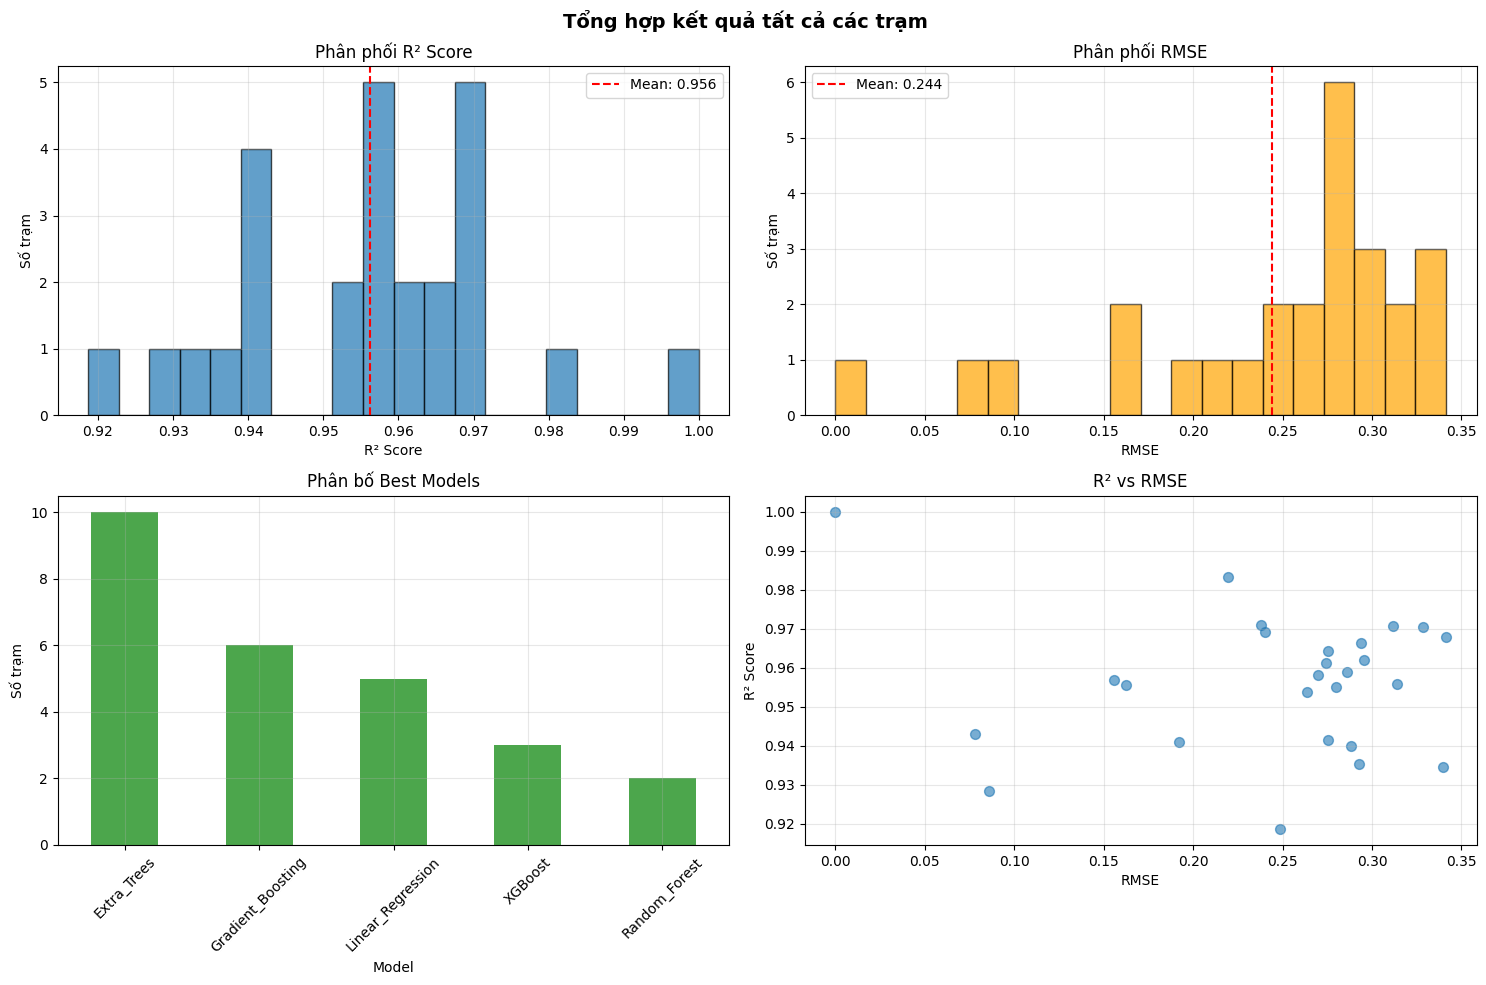

✅ Đã lưu biểu đồ tổng hợp: ensemble_results\overall_summary.png


'ensemble_results\\overall_summary.png'

In [ ]:
# ==============================================================================
# CELL 11: CREATE OVERALL VISUALIZATIONS (OPTIONAL)
# ==============================================================================

def create_overall_visualizations(summary_df):
    """Tạo visualizations tổng hợp cho tất cả trạm"""
    
    if summary_df is None or len(summary_df) == 0:
        print("❌ Không có dữ liệu để tạo biểu đồ")
        return
    
    print(f"\n📈 Đang tạo biểu đồ tổng hợp...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Tổng hợp kết quả tất cả các trạm', fontsize=14, fontweight='bold')
    
    # 1. Histogram R²
    axes[0, 0].hist(summary_df['Test_R2'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(x=summary_df['Test_R2'].mean(), color='red', linestyle='--',
                      label=f'Mean: {summary_df["Test_R2"].mean():.3f}')
    axes[0, 0].set_xlabel('R² Score')
    axes[0, 0].set_ylabel('Số trạm')
    axes[0, 0].set_title('Phân phối R² Score')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Histogram RMSE
    axes[0, 1].hist(summary_df['Test_RMSE'], bins=20, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].axvline(x=summary_df['Test_RMSE'].mean(), color='red', linestyle='--',
                      label=f'Mean: {summary_df["Test_RMSE"].mean():.3f}')
    axes[0, 1].set_xlabel('RMSE')
    axes[0, 1].set_ylabel('Số trạm')
    axes[0, 1].set_title('Phân phối RMSE')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Best models distribution
    model_dist = summary_df['Best_Model'].value_counts()
    model_dist.plot(kind='bar', ax=axes[1, 0], color='green', alpha=0.7)
    axes[1, 0].set_xlabel('Model')
    axes[1, 0].set_ylabel('Số trạm')
    axes[1, 0].set_title('Phân bố Best Models')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. R² vs RMSE scatter
    axes[1, 1].scatter(summary_df['Test_RMSE'], summary_df['Test_R2'], alpha=0.6, s=50)
    axes[1, 1].set_xlabel('RMSE')
    axes[1, 1].set_ylabel('R² Score')
    axes[1, 1].set_title('R² vs RMSE')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Lưu biểu đồ
    overall_path = os.path.join(OUTPUT_DIR, "overall_summary.png")
    plt.savefig(overall_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Đã lưu biểu đồ tổng hợp: {overall_path}")
    
    return overall_path

# Chạy tạo biểu đồ tổng hợp (nếu có kết quả)
summary_df = pd.read_csv(os.path.join(MODELS_DIR, "regression_summary.csv")) if os.path.exists(os.path.join(MODELS_DIR, "regression_summary.csv")) else None
create_overall_visualizations(summary_df)


🔍 TESTING SINGLE STATION: Tan_Chau

🚀 XỬ LÝ TRẠM: Tan_Chau
📥 Đang tải và xử lý dữ liệu...
📊 Số features sẵn có: 35/35
📊 Tổng số features ban đầu: 35
📈 Train samples: 7670

🎯 Áp dụng feature selection...

🔍 Đang phân tích feature importance cho Tan_Chau...
📊 Tính Pearson Correlation...
🌲 Tính Random Forest Importance...

✅ ĐÃ CHỌN 25/35 FEATURES CHO Tan_Chau:
  🔹 Mực nước (Water Level) (15): wl_delta_1, wl_delta_3, wl_lag_1, wl_lag_14, wl_lag_2...
  🔹 Lượng mưa (Rainfall) (4): rain_ma_14, rain_ma_7, rain_temp_interaction, rainfall
  🔹 Nhiệt độ (Temperature) (3): rain_temp_interaction, temp_ma_14, temperature_2m_max
  🔹 Tương tác (Interactions) (1): rain_temp_interaction
  🔹 Thời gian (Temporal) (4): cos_doy, month, season, sin_doy
📈 Đã lưu biểu đồ feature importance: ensemble_results\Tan_Chau\Tan_Chau_feature_importance.png
✅ Số features sau selection: 25 (giảm 10)
⚙️ Chuẩn hóa dữ liệu...
📊 Chia dữ liệu: Train=6136, Validation=1534

🤖 Đang huấn luyện các models...
  Linear_Regression  

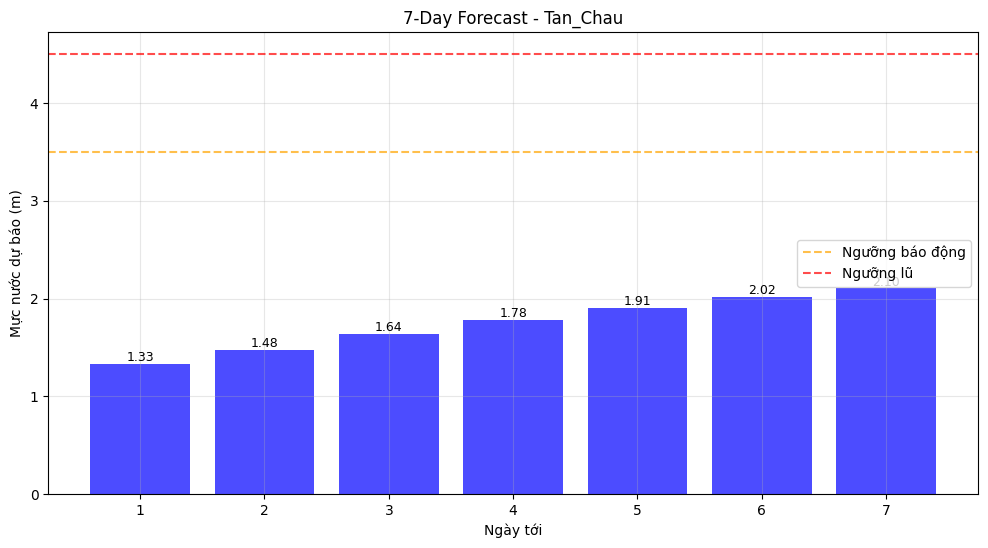

📈 Đã lưu forecast plot: ensemble_results\Tan_Chau\Tan_Chau_forecast_plot.png

💾 Đang lưu kết quả cho Tan_Chau...
   ✅ Model: models\regression\best_regressor_Tan_Chau.pkl
   ✅ Scaler: models\scalers\scaler_Tan_Chau.pkl
   ✅ Forecast: models\forecasts\Tan_Chau_forecast.csv
   ✅ Results: ensemble_results\Tan_Chau\Tan_Chau_results.csv
   ✅ Summary: ensemble_results\Tan_Chau\Tan_Chau_summary.json

✅ Đã hoàn thành test Tan_Chau


({'model': LinearRegression(),
  'model_name': 'Linear_Regression',
  'scaler': StandardScaler(),
  'features': ['cos_doy',
   'month',
   'rain_ma_14',
   'rain_ma_7',
   'rain_temp_interaction',
   'rainfall',
   'season',
   'sin_doy',
   'temp_ma_14',
   'temperature_2m_max',
   'wl_delta_1',
   'wl_delta_3',
   'wl_lag_1',
   'wl_lag_14',
   'wl_lag_2',
   'wl_lag_3',
   'wl_lag_30',
   'wl_lag_365',
   'wl_lag_7',
   'wl_ma_14',
   'wl_ma_30',
   'wl_ma_7',
   'wl_max_7',
   'wl_min_7',
   'wl_std_7'],
  'station_name': 'Tan_Chau',
  'station_info': {'station_id': '019803',
   'station_name': 'Tan_Chau',
   'country': 'VN',
   'unit_rainfall': 'mm',
   'unit_water_level': 'm',
   'latitude': 10.80062,
   'longitude': 105.24802,
   'elevation': 0.0,
   'dist_to_ocean_km': 190.89,
   'floodStage': 4.5,
   'alarmStage': 3.5},
  'val_rmse': 0.25123008529038615,
  'val_r2': 0.9171513809086732,
  'test_rmse': 0.24835808799252243,
  'test_r2': 0.9186911216064332,
  'feature_selection_ap

In [11]:
# ==============================================================================
# CELL 12: TEST SINGLE STATION (OPTIONAL FOR DEBUGGING)
# ==============================================================================

def test_single_station(station_name):
    """Test một trạm duy nhất (dùng cho debugging)"""
    
    station_dir = os.path.join(BASE_DATA_DIR, station_name)
    
    if not os.path.exists(station_dir):
        print(f"❌ Không tìm thấy trạm: {station_name}")
        return
    
    print(f"\n🔍 TESTING SINGLE STATION: {station_name}")
    print(f"{'='*60}")
    
    try:
        # 1. Huấn luyện và đánh giá
        best_model_info, results_df, station_info = train_and_evaluate_station(station_dir)
        
        if best_model_info is None:
            print("❌ Không thể huấn luyện model")
            return
        
        # 2. Tạo 7-day forecast
        forecast_df = create_7day_forecast(best_model_info)
        
        # 3. Tạo forecast visualization
        if forecast_df is not None and station_info:
            create_forecast_plot(station_name, forecast_df, station_info)
        
        # 4. Lưu kết quả
        summary = save_station_results(
            station_name, best_model_info, results_df, forecast_df
        )
        
        print(f"\n✅ Đã hoàn thành test {station_name}")
        
        return best_model_info, results_df, forecast_df
        
    except Exception as e:
        print(f"❌ Lỗi khi test {station_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Để test một trạm cụ thể, chạy:
test_single_station("Tan_Chau")  # Thay "Tan_Chau" bằng tên trạm thực tế

In [12]:
# ==============================================================================
# CELL 13: LOAD BEST MODELS & TEST 7-DAY ROLLING FORECAST
# ==============================================================================

def load_best_model_for_station(station_name):
    """
    Load best model đã lưu cho một trạm
    """
    print(f"\n📂 Đang load model cho {station_name}...")
    
    # Đường dẫn model đã lưu
    model_path = os.path.join(REGRESSION_DIR, f"best_regressor_{station_name}.pkl")
    scaler_path = os.path.join(SCALERS_DIR, f"scaler_{station_name}.pkl")
    
    if not os.path.exists(model_path):
        print(f"❌ Không tìm thấy model: {model_path}")
        return None
    
    if not os.path.exists(scaler_path):
        print(f"❌ Không tìm thấy scaler: {scaler_path}")
        return None
    
    try:
        # Load model artifact
        model_artifact = joblib.load(model_path)
        scaler = joblib.load(scaler_path)
        
        print(f"✅ Đã load model: {model_artifact['model_name']}")
        print(f"   Features: {len(model_artifact['features'])}")
        print(f"   Test RMSE: {model_artifact.get('test_rmse', 'N/A')}")
        print(f"   Test R²: {model_artifact.get('test_r2', 'N/A')}")
        
        # Tạo model info dictionary
        model_info = {
            "model": model_artifact["model"],
            "model_name": model_artifact["model_name"],
            "scaler": scaler,
            "features": model_artifact["features"],
            "station_name": station_name,
            "test_rmse": model_artifact.get("test_rmse"),
            "test_r2": model_artifact.get("test_r2")
        }
        
        return model_info
        
    except Exception as e:
        print(f"❌ Lỗi load model: {str(e)}")
        return None

def test_7day_rolling_forecast_single(station_name, horizon=7):
    """
    Test 7-day rolling forecast cho một trạm cụ thể (dùng model đã lưu)
    """
    print(f"\n{'='*60}")
    print(f"🔬 TEST 7-DAY ROLLING FORECAST: {station_name}")
    print(f"{'='*60}")
    
    # 1. Load model đã lưu
    model_info = load_best_model_for_station(station_name)
    
    if model_info is None:
        print(f"❌ Không thể load model cho {station_name}")
        return None
    
    # 2. Load dữ liệu test
    station_dir = os.path.join(BASE_DATA_DIR, station_name)
    test_path = os.path.join(station_dir, "test.csv")
    
    if not os.path.exists(test_path):
        print(f"❌ Không tìm thấy test data: {test_path}")
        return None
    
    # 3. Load dữ liệu train để có history
    train_path = os.path.join(station_dir, "train.csv")
    
    if not os.path.exists(train_path):
        print(f"❌ Không tìm thấy train data: {train_path}")
        return None
    
    print("📥 Đang load dữ liệu train/test...")
    train_df = load_and_preprocess(train_path)
    test_df = load_and_preprocess(test_path)
    
    # 4. Kết hợp train + test để có đủ context
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    
    print(f"📊 Train samples: {len(train_df)}")
    print(f"📊 Test samples: {len(test_df)}")
    print(f"📊 Total samples: {len(full_df)}")
    print(f"📅 Test period: {test_df['date'].min().date()} to {test_df['date'].max().date()}")
    
    # 5. Chuẩn bị model và features
    model = model_info["model"]
    scaler = model_info["scaler"]
    features = model_info["features"]
    
    # 6. Thực hiện rolling forecast
    print(f"\n🔄 Thực hiện {horizon}-day rolling forecast...")
    
    test_start_idx = len(train_df)
    test_end_idx = len(full_df)
    
    # Số lượng forecasts có thể thực hiện
    n_forecasts = len(test_df) - horizon + 1  # Giới hạn 20 forecasts để test nhanh
    print(f"🎯 Sẽ thực hiện {n_forecasts} rolling forecasts")
    
    all_predictions = []
    all_actuals = []
    forecast_dates = []
    
    for i in range(n_forecasts):
        # Start index cho forecast này
        forecast_start = test_start_idx + i
        
        # Lấy history (train + các ngày test đã biết trước đó)
        history_df = full_df.iloc[:forecast_start].copy()
        
        # Ngày bắt đầu forecast
        forecast_start_date = full_df.iloc[forecast_start]["date"]
        
        # Tạo forecast cho horizon ngày
        predictions = []
        actuals = []
        dates = []
        
        # Copy history để update trong quá trình recursive forecast
        current_history = history_df.copy()
        
        for day in range(horizon):
            # Ngày cần dự báo
            target_idx = forecast_start + day
            if target_idx >= len(full_df):
                break
            
            target_date = full_df.iloc[target_idx]["date"]
            actual_value = full_df.iloc[target_idx]["water_level"]
            
            try:
                # Tạo features cho ngày này
                forecast_features = create_simple_forecast_row(
                    current_history, features, target_date
                )
                
                if forecast_features is not None:
                    # Xử lý NaN
                    forecast_features = forecast_features.fillna(0)
                    
                    # Đảm bảo có đủ features
                    missing_features = [f for f in features if f not in forecast_features.columns]
                    if missing_features:
                        for f in missing_features:
                            forecast_features[f] = 0
                    
                    # Chuẩn hóa và dự báo
                    X_forecast = scaler.transform(forecast_features[features].values.reshape(1, -1))
                    prediction = model.predict(X_forecast)[0]
                    
                    predictions.append(prediction)
                    actuals.append(actual_value)
                    dates.append(target_date)
                    
                    # Cập nhật history với prediction (cho recursive forecast)
                    new_row = current_history.iloc[-1:].copy()
                    new_row["date"] = target_date
                    new_row["water_level"] = prediction
                    
                    # Dùng actual weather data nếu có
                    if target_idx < len(full_df):
                        for col in ["rainfall", "precipitation_sum", "temperature_2m_max", "et0_fao_evapotranspiration"]:
                            if col in full_df.columns:
                                new_row[col] = full_df.iloc[target_idx][col]
                    
                    current_history = pd.concat([current_history, new_row], ignore_index=True)
                    current_history = add_features_without_leak(current_history, is_training=False)
                
                else:
                    # Không thể tạo features
                    predictions.append(np.nan)
                    actuals.append(actual_value)
                    dates.append(target_date)
                    
            except Exception as e:
                predictions.append(np.nan)
                actuals.append(actual_value)
                dates.append(target_date)
                print(f"⚠️  Lỗi forecast ngày {day+1}: {str(e)[:50]}")
        
        # Lưu kết quả forecast này
        if len(predictions) > 0:
            all_predictions.append(predictions)
            all_actuals.append(actuals)
            forecast_dates.append(forecast_start_date)
        
        # Progress
        if (i + 1) % 5 == 0:
            print(f"  Đã hoàn thành {i+1}/{n_forecasts} forecasts")
    
    # 7. Tính metrics và hiển thị kết quả
    print(f"\n📊 Tính toán metrics...")
    
    # Tạo DataFrame kết quả
    results_by_day = []
    
    for day in range(horizon):
        day_predictions = []
        day_actuals = []
        
        for forecast_idx in range(len(all_predictions)):
            if day < len(all_predictions[forecast_idx]):
                pred = all_predictions[forecast_idx][day]
                actual = all_actuals[forecast_idx][day]
                
                if not np.isnan(pred):
                    day_predictions.append(pred)
                    day_actuals.append(actual)
        
        if len(day_predictions) > 0:
            rmse = np.sqrt(mean_squared_error(day_actuals, day_predictions))
            mae = mean_absolute_error(day_actuals, day_predictions)
            r2 = r2_score(day_actuals, day_predictions)
            
            results_by_day.append({
                "forecast_day": day + 1,
                "n_samples": len(day_predictions),
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "mean_prediction": np.mean(day_predictions),
                "mean_actual": np.mean(day_actuals)
            })
    
    # Tính overall metrics
    all_pred_flat = []
    all_actual_flat = []
    
    for pred_list, actual_list in zip(all_predictions, all_actuals):
        for pred, actual in zip(pred_list, actual_list):
            if not np.isnan(pred):
                all_pred_flat.append(pred)
                all_actual_flat.append(actual)
    
    if len(all_pred_flat) > 0:
        overall_rmse = np.sqrt(mean_squared_error(all_actual_flat, all_pred_flat))
        overall_mae = mean_absolute_error(all_actual_flat, all_pred_flat)
        overall_r2 = r2_score(all_actual_flat, all_pred_flat)
        
        print(f"\n🏆 OVERALL {horizon}-DAY FORECAST PERFORMANCE:")
        print(f"   Total predictions: {len(all_pred_flat)}")
        print(f"   Overall RMSE: {overall_rmse:.4f}")
        print(f"   Overall MAE:  {overall_mae:.4f}")
        print(f"   Overall R²:   {overall_r2:.4f}")
        
        if model_info.get("test_rmse"):
            print(f"   Compare to 1-day test RMSE: {model_info['test_rmse']:.4f}")
            print(f"   Degradation: {overall_rmse - model_info['test_rmse']:+.4f}")
    
    print(f"\n📅 PERFORMANCE BY FORECAST DAY:")
    if results_by_day:
        results_df = pd.DataFrame(results_by_day)
        print(results_df.to_string(index=False))
    
    # 8. Vẽ biểu đồ kết quả
    plot_rolling_forecast_results(station_name, results_by_day, all_predictions, 
                                  all_actuals, forecast_dates, horizon)
    
    return {
        "station": station_name,
        "model_name": model_info["model_name"],
        "horizon": horizon,
        "n_forecasts": n_forecasts,
        "n_predictions": len(all_pred_flat),
        "overall_rmse": overall_rmse if len(all_pred_flat) > 0 else None,
        "overall_mae": overall_mae if len(all_pred_flat) > 0 else None,
        "overall_r2": overall_r2 if len(all_pred_flat) > 0 else None,
        "by_day": results_by_day,
        "forecast_dates": forecast_dates
    }

def create_simple_forecast_row(history_df, features, target_date):
    """Tạo features đơn giản cho forecast"""
    try:
        # Tạo row mới
        new_row = history_df.iloc[-1:].copy()
        new_row["date"] = target_date
        
        # Cập nhật temporal features
        new_row["dayofyear"] = target_date.timetuple().tm_yday
        new_row["sin_doy"] = np.sin(2 * np.pi * new_row["dayofyear"] / 365.25)
        new_row["cos_doy"] = np.cos(2 * np.pi * new_row["dayofyear"] / 365.25)
        new_row["month"] = target_date.month
        new_row["year"] = target_date.year
        new_row["day_of_month"] = target_date.day
        new_row["season"] = target_date.month % 12 // 3 + 1
        new_row["is_weekend"] = target_date.weekday() >= 5
        
        # Kết hợp và tính features
        combined = pd.concat([history_df, new_row], ignore_index=True)
        combined = add_features_without_leak(combined, is_training=False)
        
        # Lấy row cuối cùng
        forecast_row = combined.iloc[-1:]
        
        # Kiểm tra và fill missing features
        missing = [f for f in features if f not in forecast_row.columns or pd.isna(forecast_row[f].iloc[0])]
        if missing:
            for f in missing:
                if f in history_df.columns:
                    forecast_row[f] = history_df[f].mean()
                else:
                    forecast_row[f] = 0
        
        return forecast_row
    
    except Exception as e:
        print(f"⚠️  Lỗi tạo forecast row: {str(e)}")
        return None

def plot_rolling_forecast_results(station_name, results_by_day, all_predictions, 
                                 all_actuals, forecast_dates, horizon):
    """Vẽ biểu đồ kết quả rolling forecast"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'{horizon}-Day Rolling Forecast Test - {station_name}', 
                 fontsize=14, fontweight='bold')
    
    # 1. Error metrics theo forecast day
    if results_by_day:
        days = [r["forecast_day"] for r in results_by_day]
        rmse_values = [r["rmse"] for r in results_by_day]
        mae_values = [r["mae"] for r in results_by_day]
        
        axes[0, 0].plot(days, rmse_values, 'o-', label='RMSE', linewidth=2, markersize=8)
        axes[0, 0].plot(days, mae_values, 's-', label='MAE', linewidth=2, markersize=8)
        axes[0, 0].set_xlabel('Forecast Day')
        axes[0, 0].set_ylabel('Error (m)')
        axes[0, 0].set_title('Error Increase Over Forecast Horizon')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # 2. R² theo forecast day
    if results_by_day:
        r2_values = [r["r2"] for r in results_by_day]
        axes[0, 1].plot(days, r2_values, 'o-', color='green', linewidth=2, markersize=8)
        axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].set_xlabel('Forecast Day')
        axes[0, 1].set_ylabel('R² Score')
        axes[0, 1].set_title('R² Degradation Over Time')
        axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Sample forecast visualization (first 3 forecasts)
    if len(all_predictions) >= 3 and len(all_actuals) >= 3:
        colors = ['blue', 'green', 'red']
        for i in range(min(3, len(all_predictions))):
            preds = all_predictions[i]
            actuals_list = all_actuals[i]
            days_range = list(range(1, len(preds) + 1))
            
            axes[1, 0].plot(days_range, preds, 'o-', color=colors[i], 
                           alpha=0.7, label=f'Forecast {i+1}', linewidth=2)
            axes[1, 0].plot(days_range, actuals_list, 'x--', color=colors[i], 
                           alpha=0.7, linewidth=1, markersize=8)
        
        axes[1, 0].set_xlabel('Forecast Day')
        axes[1, 0].set_ylabel('Water Level (m)')
        axes[1, 0].set_title('Sample Forecasts vs Actual (First 3)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Error distribution
    all_errors = []
    for pred_list, actual_list in zip(all_predictions, all_actuals):
        for pred, actual in zip(pred_list, actual_list):
            if not np.isnan(pred):
                all_errors.append(actual - pred)
    
    if all_errors:
        axes[1, 1].hist(all_errors, bins=30, edgecolor='black', alpha=0.7, color='purple')
        axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1, 1].axvline(x=np.mean(all_errors), color='blue', linestyle='--', 
                          linewidth=2, label=f'Mean: {np.mean(all_errors):.3f}')
        axes[1, 1].set_xlabel('Prediction Error (m)')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title(f'Error Distribution (n={len(all_errors)})')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Lưu biểu đồ
    station_output_dir = os.path.join(OUTPUT_DIR, station_name)
    os.makedirs(station_output_dir, exist_ok=True)
    
    plot_path = os.path.join(station_output_dir, f"{station_name}_rolling_forecast_test.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"📈 Đã lưu biểu đồ: {plot_path}")

def test_multiple_stations_rolling_forecast(station_names=None, horizon=7):
    """
    Test rolling forecast cho nhiều trạm
    """
    print(f"\n{'='*60}")
    print(f"🎯 TEST ROLLING FORECAST FOR MULTIPLE STATIONS")
    print(f"{'='*60}")
    
    # Nếu không chỉ định, tìm tất cả trạm có model
    if station_names is None:
        print("🔍 Tìm tất cả trạm có model đã lưu...")
        station_names = []
        
        for item in os.listdir(BASE_DATA_DIR):
            if os.path.isdir(os.path.join(BASE_DATA_DIR, item)):
                model_path = os.path.join(REGRESSION_DIR, f"best_regressor_{item}.pkl")
                if os.path.exists(model_path):
                    station_names.append(item)
        
        print(f"📁 Tìm thấy {len(station_names)} trạm có model")
    
    if not station_names:
        print("❌ Không tìm thấy trạm nào có model!")
        return None
    
    all_results = []
    
    # Test từng trạm
    for i, station_name in enumerate(station_names[:5], 1):  # Chỉ test 5 trạm đầu
        print(f"\n📊 [{i}/{min(5, len(station_names))}] Testing: {station_name}")
        
        try:
            result = test_7day_rolling_forecast_single(station_name, horizon)
            
            if result:
                all_results.append(result)
                print(f"✅ Đã test xong {station_name}")
                
        except Exception as e:
            print(f"❌ Lỗi test {station_name}: {str(e)[:100]}")
            import traceback
            traceback.print_exc()
    
    # Tổng hợp kết quả
    if all_results:
        print(f"\n{'='*60}")
        print("📊 TỔNG HỢP KẾT QUẢ ROLLING FORECAST TEST")
        print(f"{'='*60}")
        
        summary_data = []
        for result in all_results:
            summary_data.append({
                "Station": result["station"],
                "Model": result.get("model_name", "N/A"),
                "Forecasts": result["n_forecasts"],
                "Predictions": result["n_predictions"],
                "Overall_RMSE": result.get("overall_rmse", "N/A"),
                "Overall_R2": result.get("overall_r2", "N/A")
            })
        
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        
        # Lưu summary
        summary_path = os.path.join(OUTPUT_DIR, "rolling_forecast_test_summary.csv")
        summary_df.to_csv(summary_path, index=False)
        
        print(f"\n📁 Đã lưu tổng hợp: {summary_path}")
        
        # Phân tích thêm
        if "Overall_RMSE" in summary_df.columns:
            valid_rmse = pd.to_numeric(summary_df["Overall_RMSE"], errors='coerce').dropna()
            if len(valid_rmse) > 0:
                print(f"\n📈 THỐNG KÊ:")
                print(f"   RMSE trung bình: {valid_rmse.mean():.4f}")
                print(f"   RMSE tốt nhất:   {valid_rmse.min():.4f}")
                print(f"   RMSE tệ nhất:    {valid_rmse.max():.4f}")
        
        return summary_df
    
    return None

print("✅ Đã định nghĩa hàm test rolling forecast với model đã lưu")

✅ Đã định nghĩa hàm test rolling forecast với model đã lưu


🎯 ROLLING FORECAST TEST WITH SAVED MODELS
📊 Load các best model đã lưu và test 7-day rolling forecast
🎯 Đánh giá realistic performance trên test set

🔬 TEST 7-DAY ROLLING FORECAST: Tan_Chau

📂 Đang load model cho Tan_Chau...
✅ Đã load model: Linear_Regression
   Features: 25
   Test RMSE: 0.24835808799252243
   Test R²: 0.9186911216064332
📥 Đang load dữ liệu train/test...
📊 Train samples: 7671
📊 Test samples: 1813
📊 Total samples: 9484
📅 Test period: 2021-01-01 to 2025-12-18

🔄 Thực hiện 7-day rolling forecast...
🎯 Sẽ thực hiện 1807 rolling forecasts
  Đã hoàn thành 5/1807 forecasts
  Đã hoàn thành 10/1807 forecasts
  Đã hoàn thành 15/1807 forecasts
  Đã hoàn thành 20/1807 forecasts
  Đã hoàn thành 25/1807 forecasts
  Đã hoàn thành 30/1807 forecasts
  Đã hoàn thành 35/1807 forecasts
  Đã hoàn thành 40/1807 forecasts
  Đã hoàn thành 45/1807 forecasts
  Đã hoàn thành 50/1807 forecasts
  Đã hoàn thành 55/1807 forecasts
  Đã hoàn thành 60/1807 forecasts
  Đã hoàn thành 65/1807 forecasts
  

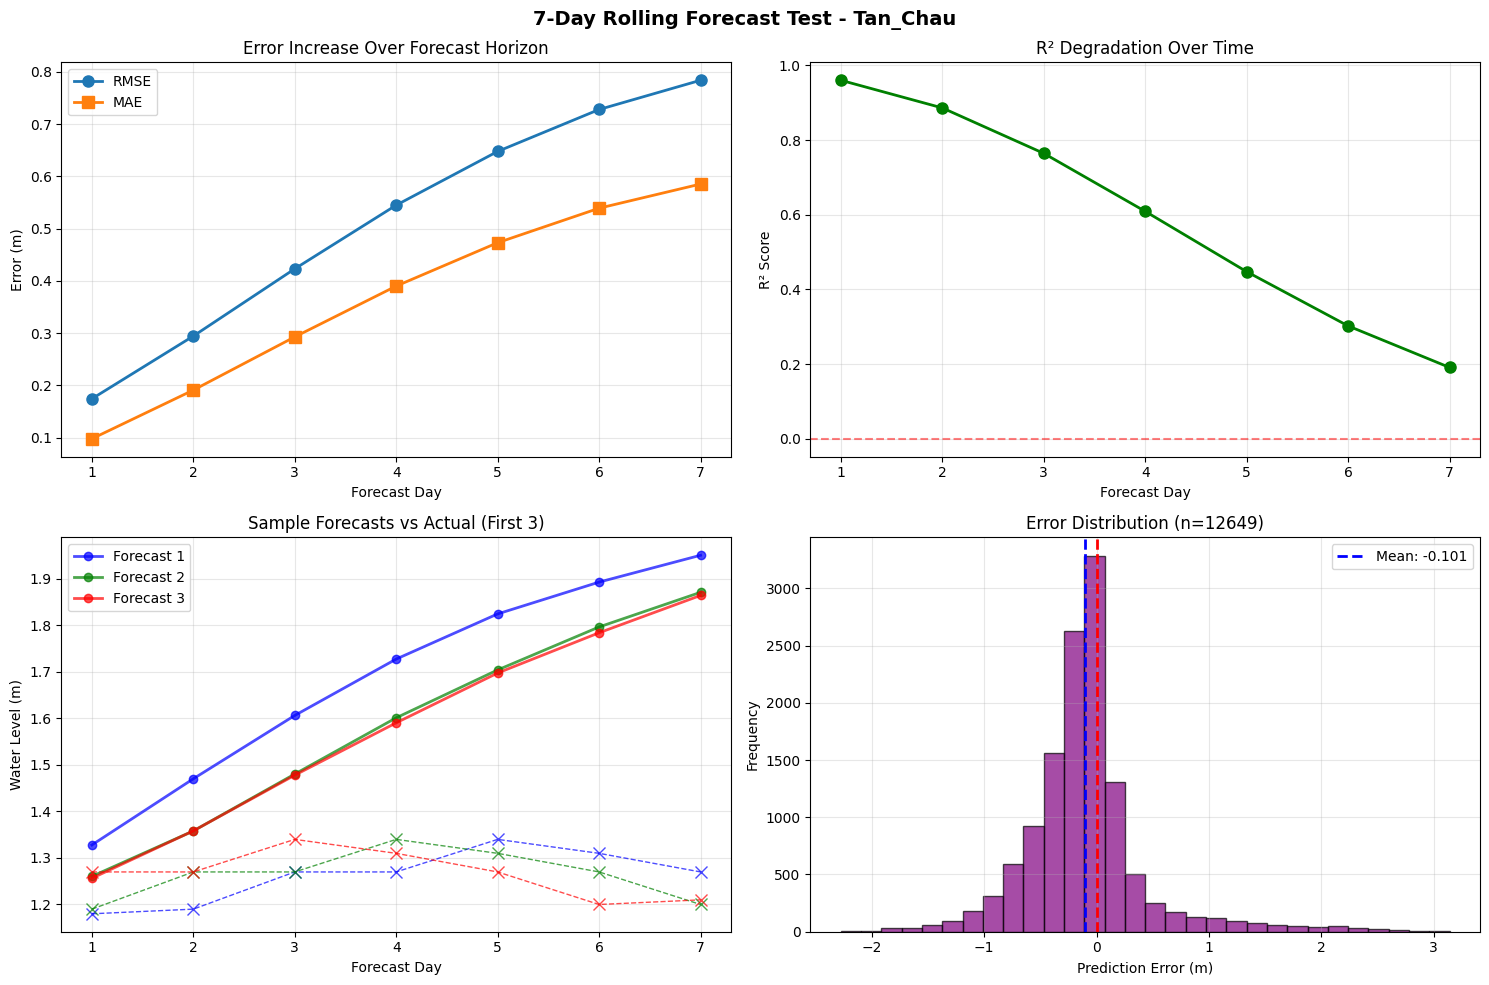

📈 Đã lưu biểu đồ: ensemble_results\Tan_Chau\Tan_Chau_rolling_forecast_test.png


{'station': 'Tan_Chau',
 'model_name': 'Linear_Regression',
 'horizon': 7,
 'n_forecasts': 1807,
 'n_predictions': 12649,
 'overall_rmse': 0.5551019866613597,
 'overall_mae': 0.3669663372713457,
 'overall_r2': 0.5943219732968381,
 'by_day': [{'forecast_day': 1,
   'n_samples': 1807,
   'rmse': 0.17423630750712985,
   'mae': 0.09771084619645495,
   'r2': 0.9600461400955002,
   'mean_prediction': 1.9011938782723543,
   'mean_actual': 1.8855783065855007},
  {'forecast_day': 2,
   'n_samples': 1807,
   'rmse': 0.2942862679934003,
   'mae': 0.19087651850284187,
   'r2': 0.8859893546047864,
   'mean_prediction': 1.9250861643807837,
   'mean_actual': 1.8857885998893194},
  {'forecast_day': 3,
   'n_samples': 1807,
   'rmse': 0.42305821571089747,
   'mae': 0.2927444034555968,
   'r2': 0.7643329938080692,
   'mean_prediction': 1.9560364150494836,
   'mean_actual': 1.8859324847814056},
  {'forecast_day': 4,
   'n_samples': 1807,
   'rmse': 0.5448862787429223,
   'mae': 0.3900215113778013,
   'r2

In [14]:
# ==============================================================================
# CELL 14: CHẠY TEST ROLLING FORECAST
# ==============================================================================

print("🎯 ROLLING FORECAST TEST WITH SAVED MODELS")
print("="*60)
print("📊 Load các best model đã lưu và test 7-day rolling forecast")
print("🎯 Đánh giá realistic performance trên test set")
print("="*60)

# Option 1: Test một trạm cụ thể
test_7day_rolling_forecast_single("Tan_Chau")
# summary = None
# # Option 2: Test nhiều trạm
# summary = test_multiple_stations_rolling_forecast()

# if summary is not None:
#     print(f"\n{'='*60}")
#     print("🎉 HOÀN THÀNH ROLLING FORECAST TEST!")
#     print(f"{'='*60}")
    
#     # Hiển thị insights
#     print(f"\n🔍 INSIGHTS TỪ KẾT QUẢ:")
#     print(f"   1. Model có thể dự báo chính xác trong bao nhiêu ngày?")
#     print(f"   2. Performance degradation như thế nào?")
#     print(f"   3. Model nào tốt nhất cho dự báo trung hạn?")
    
#     print(f"\n📁 OUTPUT FILES:")
#     print(f"   {OUTPUT_DIR}/rolling_forecast_test_summary.csv")
#     print(f"   {OUTPUT_DIR}/<station_name>/<station>_rolling_forecast_test.png")
    
#     print(f"\n🎯 ĐỂ TEST THÊM:")
#     print(f"   # Test một trạm cụ thể:")
#     print(f'   test_7day_rolling_forecast_single("Ten_Tram")')
#     print(f"\n   # Test với horizon khác:")
#     print(f'   test_7day_rolling_forecast_single("Ten_Tram", horizon=14)')
    
# else:
#     print("❌ Không có kết quả test nào!")